<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_11_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Selection and Preprocessing

Import Libraries

In [1]:
import os
import cv2
import zipfile
import numpy as np
import matplotlib.pyplot as plt



from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline


In [4]:
zip_path = "/content/images (1).zip"
extract_path = "/content/images/images/images/images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted items:", os.listdir(extract_path))

data_dir = extract_path

images = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    print("Checking:", class_path)

    if os.path.isdir(class_path):
        print("Folder found:", label)

        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            print(" Reading:", img_path)

            try:
                img = cv2.imread(img_path)

                if img is None:
                    print("  Could not read:", img_path)
                    continue

                img = cv2.resize(img, (64, 64))
                images.append(img)
                labels.append(label)

            except Exception as e:
                print("  Error:", e)

X = np.array(images)
y = np.array(labels)

print("Dataset shape:", X.shape)
print("Labels shape:", y.shape)

Extracted items: ['pizza', 'soccer_ball', 'images', 'dalmatian', 'dollar_bill', 'sunflower']
Checking: /content/images/images/images/images/pizza
Folder found: pizza
 Reading: /content/images/images/images/images/pizza/image_0039.jpg
 Reading: /content/images/images/images/images/pizza/image_0032.jpg
 Reading: /content/images/images/images/images/pizza/image_0028.jpg
 Reading: /content/images/images/images/images/pizza/image_0042.jpg
 Reading: /content/images/images/images/images/pizza/image_0017.jpg
 Reading: /content/images/images/images/images/pizza/image_0047.jpg
 Reading: /content/images/images/images/images/pizza/image_0050.jpg
 Reading: /content/images/images/images/images/pizza/image_0019.jpg
 Reading: /content/images/images/images/images/pizza/image_0025.jpg
 Reading: /content/images/images/images/images/pizza/image_0027.jpg
 Reading: /content/images/images/images/images/pizza/image_0015.jpg
 Reading: /content/images/images/images/images/pizza/image_0022.jpg
 Reading: /content

Preprocessing

In [5]:
# Flatten image
X = X.reshape(X.shape[0], -1)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



# Model Training

Random Forest + Grid Search

In [6]:

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 20, 40],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf = RandomForestClassifier(
    random_state= 42,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)


print("Best Parameters:", rf_grid.best_params_)
print("Best Cross-Validation Score:", rf_grid.best_score_)

best_rf = rf_grid.best_estimator_

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Score: 0.7446370849250661


SVM + Grid search

# Model Evalutation

In [7]:
y_pred_rf = best_rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)

print("Random Forest Performance Results")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")


Random Forest Performance Results
Accuracy : 0.7258
Precision: 0.7387
Recall   : 0.7258
F1-score : 0.7251


Confusion Matrix

Random Forest Classification Report
              precision    recall  f1-score   support

   dalmatian       0.53      0.73      0.62        11
 dollar_bill       0.88      0.70      0.78        10
       pizza       0.89      0.73      0.80        11
 soccer_ball       0.55      0.46      0.50        13
   sunflower       0.84      0.94      0.89        17

    accuracy                           0.73        62
   macro avg       0.74      0.71      0.72        62
weighted avg       0.74      0.73      0.73        62



<Figure size 700x600 with 0 Axes>

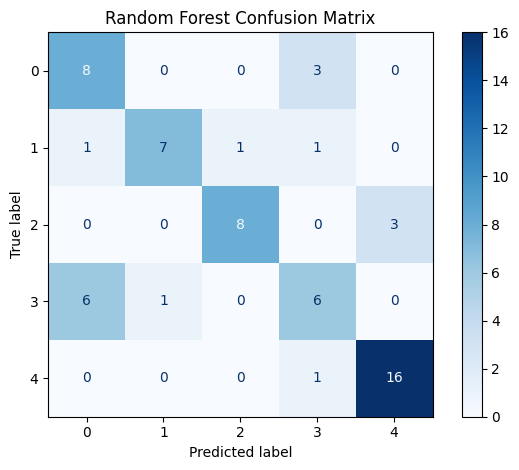

In [9]:
rf_cm = confusion_matrix(y_test, y_pred_rf)

rf_report = classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
)

print("Random Forest Classification Report")
print(rf_report)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=300)
plt.show()

# Feature Importance Visualization

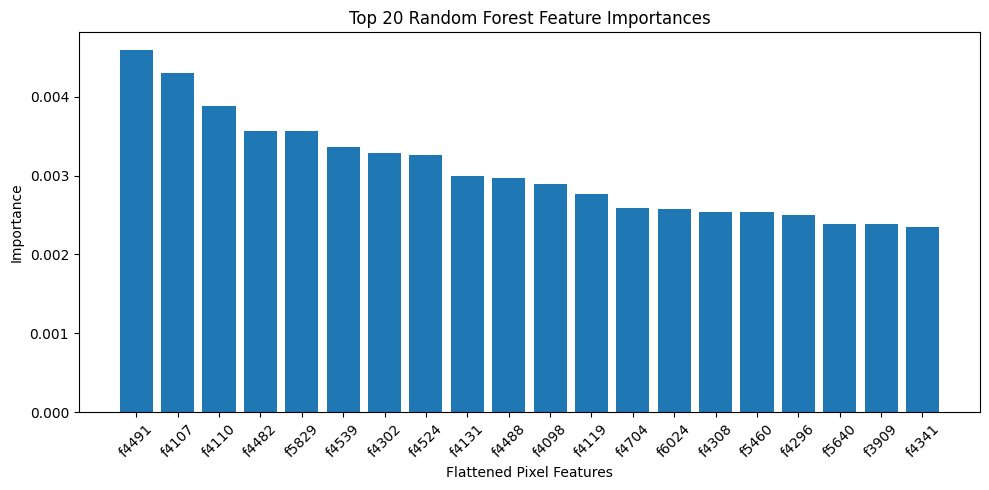

In [10]:
# Since there are many pixel features, visualize the top 20 most important.
feature_importances = best_rf.feature_importances_
top_n = 20
top_idx = np.argsort(feature_importances)[-top_n:][::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(top_n), feature_importances[top_idx])
plt.xticks(range(top_n), [f"f{i}" for i in top_idx], rotation=45)
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Flattened Pixel Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig("rf_feature_importances_top20.png", dpi=300)
plt.show()

# Prediction function for new image

In [14]:
IMAGE_SIZE = (64, 64)

img_test = "/content/057f1b6c-ec55-47d9-8275-cabf3479c3fe.jpg"

predicted_class = best_rf.predict(
    new_image_processing(img_test, IMAGE_SIZE)
)[0]

true_class = "pizza"   # or y_test[0] if using split

print("Test image predicted")
print("Image Path      :", img_test)
print("Predicted Class :", predicted_class)
print("True Class      :", true_class)

Test image predicted
Image Path      : /content/057f1b6c-ec55-47d9-8275-cabf3479c3fe.jpg
Predicted Class : sunflower
True Class      : pizza


# SVM Classification

Fitting 3 folds for each of 12 candidates, totalling 36 fits
SVM Grid
Best Parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best Cross-Validation Score: 0.7977274953472425

SVM Performance Results
Accuracy : 0.7903
Precision: 0.7966
Recall   : 0.7903
F1-score : 0.7855

SVM Classification Results
              precision    recall  f1-score   support

   dalmatian       0.67      0.73      0.70        11
 dollar_bill       0.83      0.50      0.62        10
       pizza       0.82      0.82      0.82        11
 soccer_ball       0.67      0.77      0.71        13
   sunflower       0.94      1.00      0.97        17

    accuracy                           0.79        62
   macro avg       0.79      0.76      0.76        62
weighted avg       0.80      0.79      0.79        62



<Figure size 700x600 with 0 Axes>

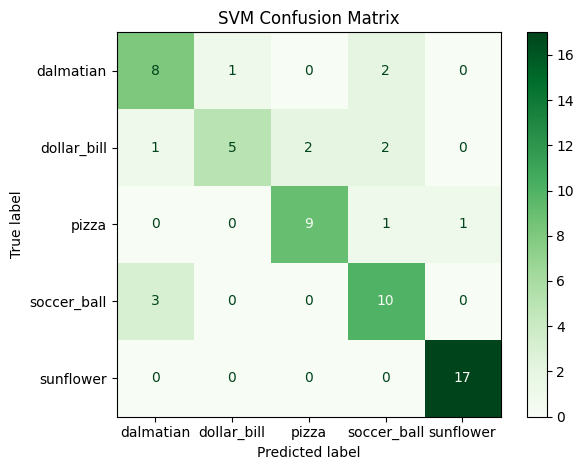

In [16]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

svm_param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svm_grid.fit(X_train, y_train)

print("SVM Grid")
print("Best Parameters:", svm_grid.best_params_)
print("Best Cross-Validation Score:", svm_grid.best_score_)

best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average="weighted", zero_division=0)
svm_recall = recall_score(y_test, y_pred_svm, average="weighted", zero_division=0)
svm_f1 = f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)

print("\nSVM Performance Results")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-score : {svm_f1:.4f}")

svm_cm = confusion_matrix(y_test, y_pred_svm)

svm_report = classification_report(
    y_test,
    y_pred_svm,
    zero_division=0
)

print("\nSVM Classification Results")
print(svm_report)

plt.figure(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=np.unique(y)
)
disp.plot(cmap="Greens", values_format="d")
plt.title("SVM Confusion Matrix")
plt.tight_layout()
plt.savefig("svm_confusion_matrix.png", dpi=300)
plt.show()

Random Forest vs SVM

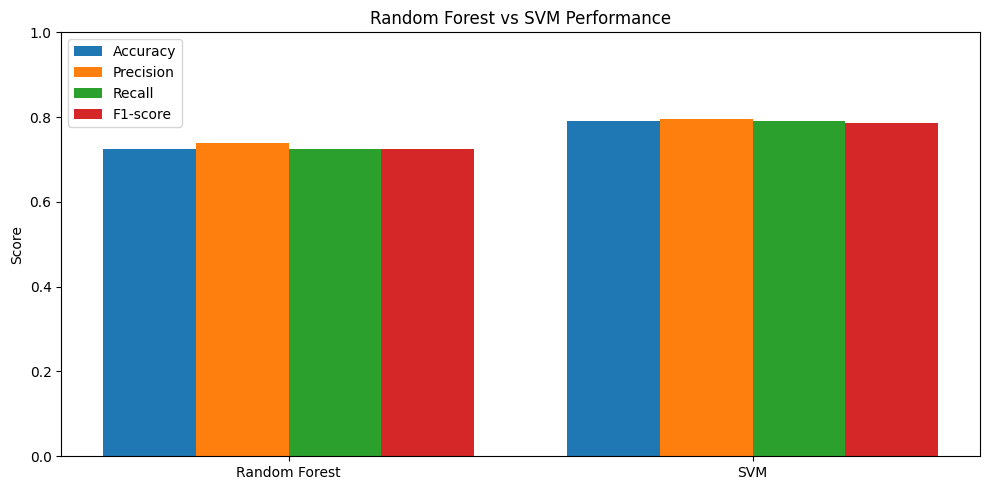

In [17]:
models = ["Random Forest", "SVM"]
accuracies = [rf_accuracy, svm_accuracy]
precisions = [rf_precision, svm_precision]
recalls = [rf_recall, svm_recall]
f1_scores = [rf_f1, svm_f1]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 5))
plt.bar(x - 1.5 * width, accuracies, width, label="Accuracy")
plt.bar(x - 0.5 * width, precisions, width, label="Precision")
plt.bar(x + 0.5 * width, recalls, width, label="Recall")
plt.bar(x + 1.5 * width, f1_scores, width, label="F1-score")
plt.xticks(x, models)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Random Forest vs SVM Performance")
plt.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()